# Feature Engineering

### Setup

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
# Setup working directory
from pathlib import Path
import os

def find_root_dir(marker='tfg'):
    p = Path.cwd()
    for candidate in [p] + list(p.parents):
        if candidate.name == marker:
            return candidate.resolve()
        if (candidate / marker).is_dir():
            return (candidate / marker).resolve()
    raise FileNotFoundError(f"Could not find '{marker}' folder in {Path.cwd()} or its parents.")

os.chdir(find_root_dir('tfg'))

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set Searborn style (background color, grid, axes, etc.) 
sns.set_style("whitegrid")

# Default values and styling for all plots
plt.rcParams.update({
    "figure.autolayout": True,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10
})
plt.rcParams["axes.grid"] = False

# Define custom colors
colors = ['crimson', 'lime']
palette = {
        'BENIGN': 'lime',
        'DDoS': 'crimson'
}

## Load Data

In [4]:
FILTERED_DATASET_PATH = "data/processed/stage2/full-225k-filtered.parquet"

In [5]:
from src.preprocessing import load_dataset
df = load_dataset(FILTERED_DATASET_PATH)
print("\nBasic Data Information:")
df.info()
print("\nFirst few rows:")
df.head()


Basic Data Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 225603 entries, 0 to 225602
Data columns (total 60 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Flow Duration                225603 non-null  int32  
 1   Total Fwd Packets            225603 non-null  int16  
 2   Total Backward Packets       225603 non-null  int16  
 3   Total Length of Fwd Packets  225603 non-null  int32  
 4   Total Length of Bwd Packets  225603 non-null  int32  
 5   Fwd Packet Length Max        225603 non-null  int16  
 6   Fwd Packet Length Min        225603 non-null  int16  
 7   Fwd Packet Length Mean       225603 non-null  float32
 8   Fwd Packet Length Std        225603 non-null  float32
 9   Bwd Packet Length Max        225603 non-null  int16  
 10  Bwd Packet Length Min        225603 non-null  int16  
 11  Bwd Packet Length Mean       225603 non-null  float32
 12  Bwd Packet Length Std        2256

,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,...,Subflow Bwd Bytes,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Max,Active Min,Idle Mean,Idle Max,Idle Min,Label
0,3,2,0,12,0,6,6,6.0,0.0,0,...,0,1,20,0.0,0,0,0.0,0,0,BENIGN
1,109,1,1,6,6,6,6,6.0,0.0,6,...,6,0,20,0.0,0,0,0.0,0,0,BENIGN
2,52,1,1,6,6,6,6,6.0,0.0,6,...,6,0,20,0.0,0,0,0.0,0,0,BENIGN
3,34,1,1,6,6,6,6,6.0,0.0,6,...,6,0,20,0.0,0,0,0.0,0,0,BENIGN
4,3,2,0,12,0,6,6,6.0,0.0,0,...,0,1,20,0.0,0,0,0.0,0,0,BENIGN


## Logarithm Transformation

In [6]:
log_feature_groups = {
    "Traffic Volume Features": [
        "Total Fwd Packets",
        "Total Backward Packets",
        "Total Length of Fwd Packets",
        "Total Length of Bwd Packets"
    ],
    "Packet Size Distribution Features": [
        "Fwd Packet Length Min",
        "Fwd Packet Length Mean",
        "Fwd Packet Length Std",
        "Bwd Packet Length Min",
        "Bwd Packet Length Mean",
        "Bwd Packet Length Std",
        "Min Packet Length",
        "Max Packet Length",
        "Packet Length Mean",
        "Packet Length Variance"
    ],
    "Time-related Features": [
        "Flow Duration",
        "Flow IAT Mean",
        "Flow IAT Std",
        "Flow IAT Max",
        "Flow IAT Min",
        "Fwd IAT Mean",
        "Fwd IAT Std",
        "Fwd IAT Min",
        "Bwd IAT Total",
        "Bwd IAT Mean",
        "Bwd IAT Std",
        "Bwd IAT Max",
        "Bwd IAT Min",
        "Active Mean",
        "Active Max",
        "Idle Mean",
        "Idle Min"
    ],
    "Traffic Rate Features": [
        "Flow Bytes/s",
        "Flow Packets/s",
        "Bwd Packets/s"
    ],
    "Header Features": [
        "Fwd Header Length",
        "Bwd Header Length"
    ],
    "Connection Features": [
        "act_data_pkt_fwd",
        "Down/Up Ratio",
        "min_seg_size_forward"
    ]
}

log_features = [
    feature
    for features in log_feature_groups.values()
    for feature in features
]

print(f"Features to be log-transformed ({len(log_features)}):")
print(log_features)

Features to be log-transformed (39):
['Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Variance', 'Flow Duration', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Active Mean', 'Active Max', 'Idle Mean', 'Idle Min', 'Flow Bytes/s', 'Flow Packets/s', 'Bwd Packets/s', 'Fwd Header Length', 'Bwd Header Length', 'act_data_pkt_fwd', 'Down/Up Ratio', 'min_seg_size_forward']


In [7]:
import numpy as np
log_feature_columns = [
    feature
    for features in log_feature_groups.values()
    for feature in features
]

df[log_features] = np.log1p(df[log_features])

assert np.isfinite(df[log_features].to_numpy()).all()

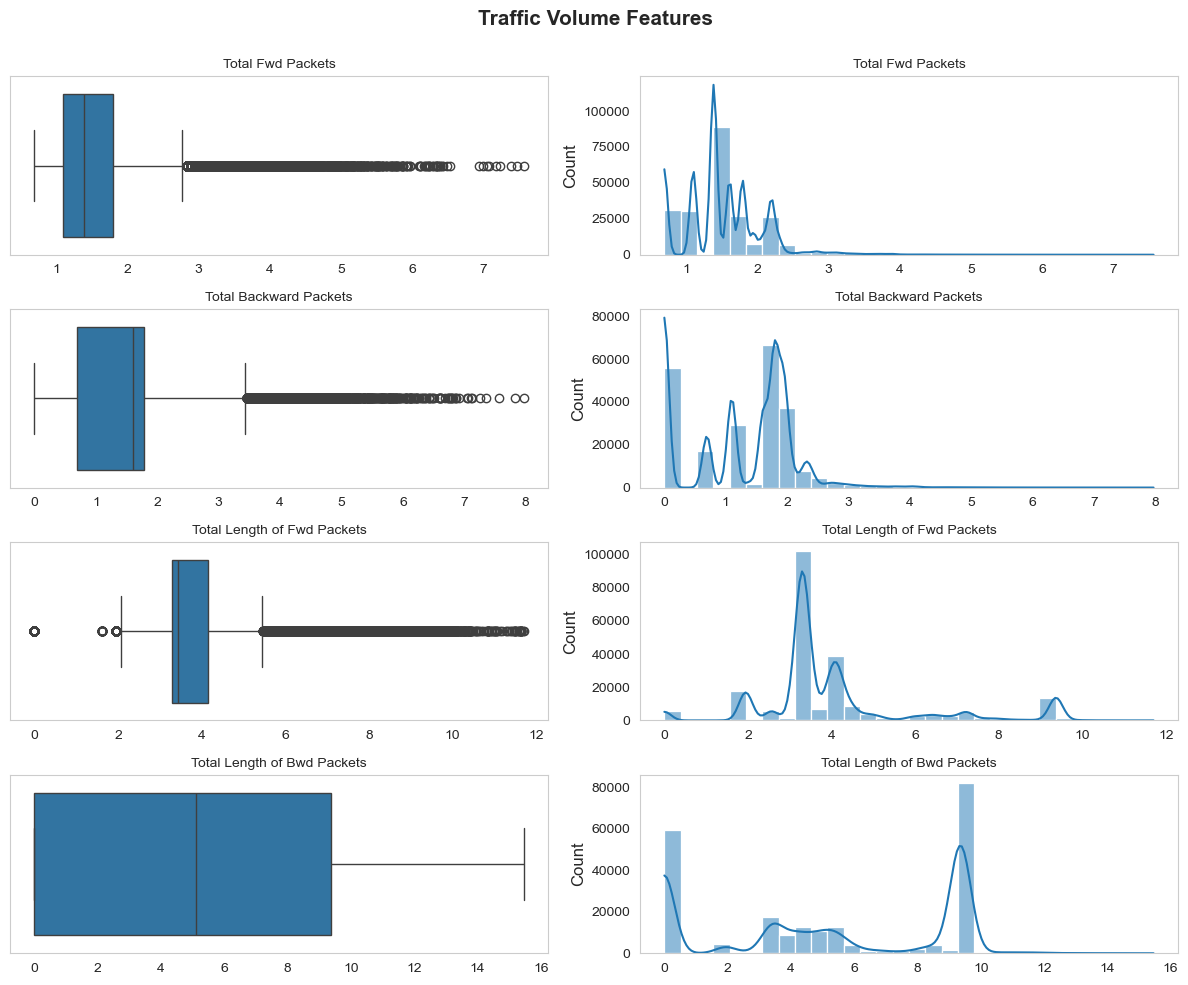

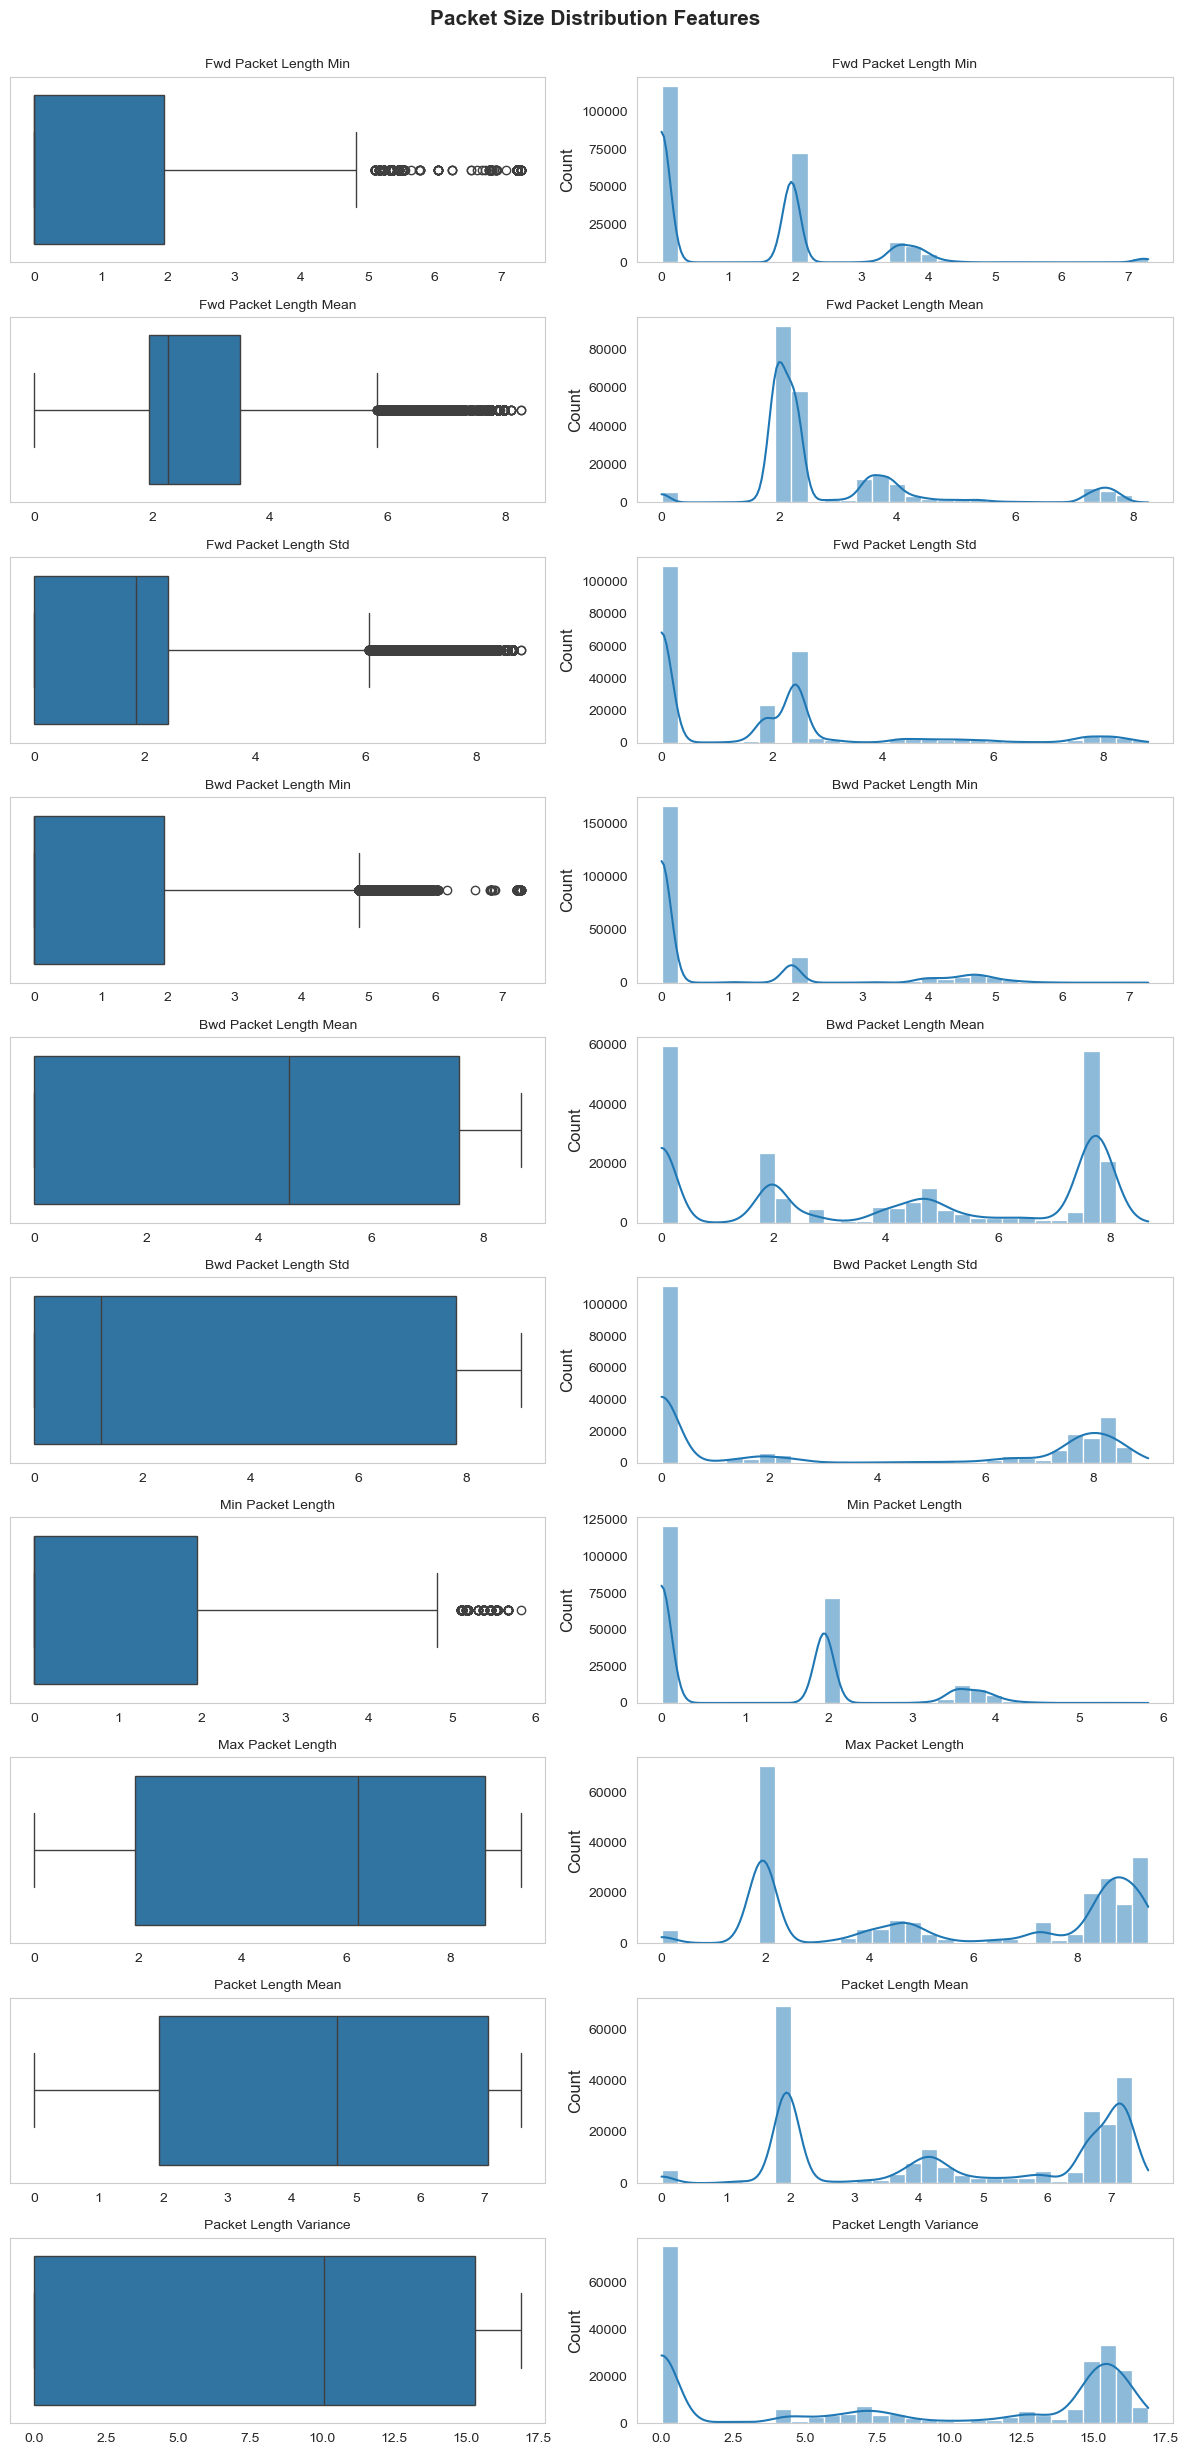

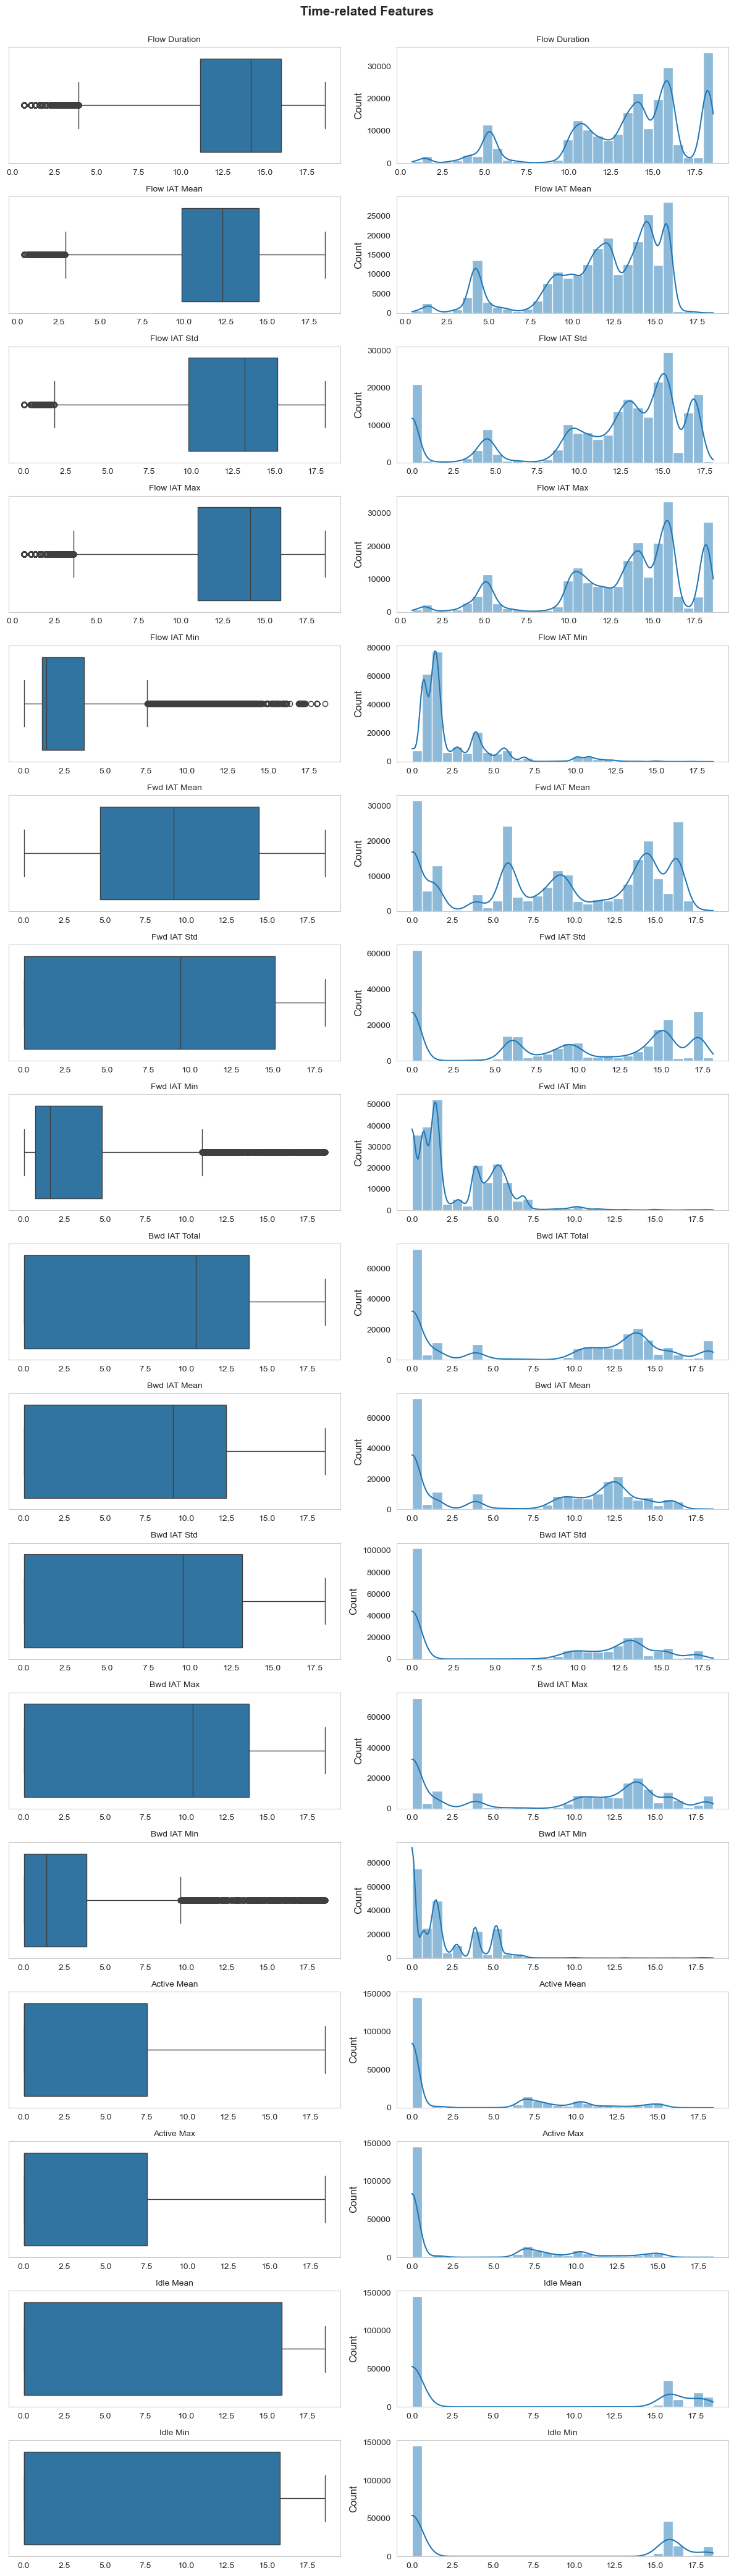

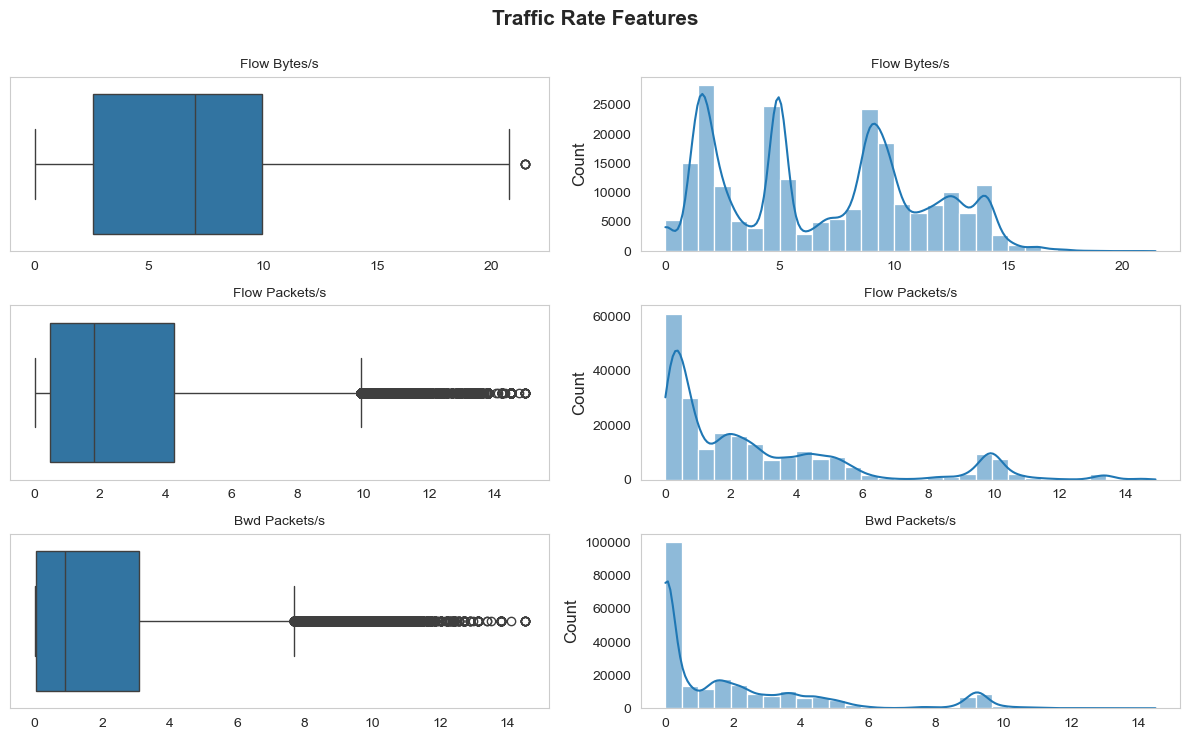

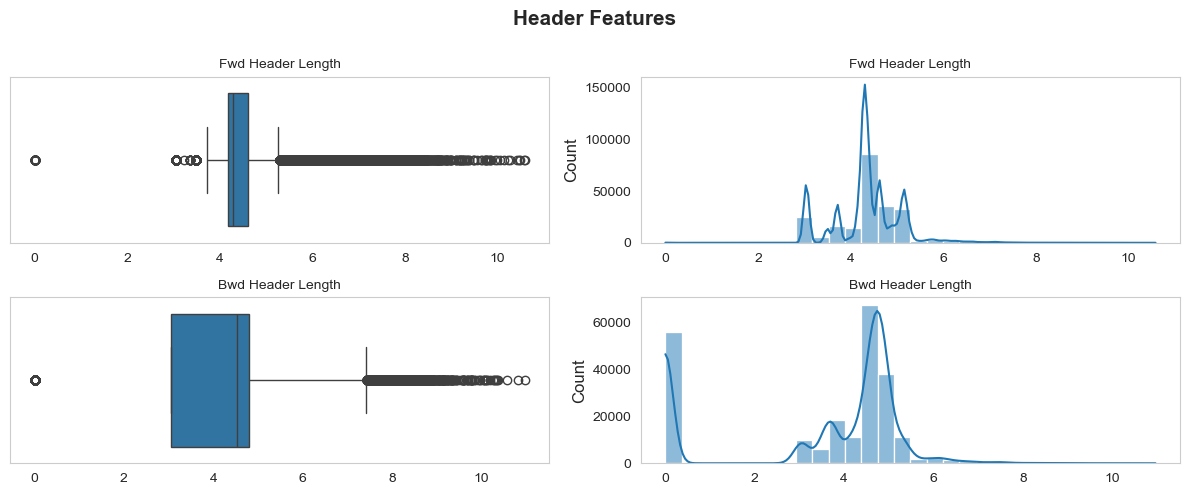

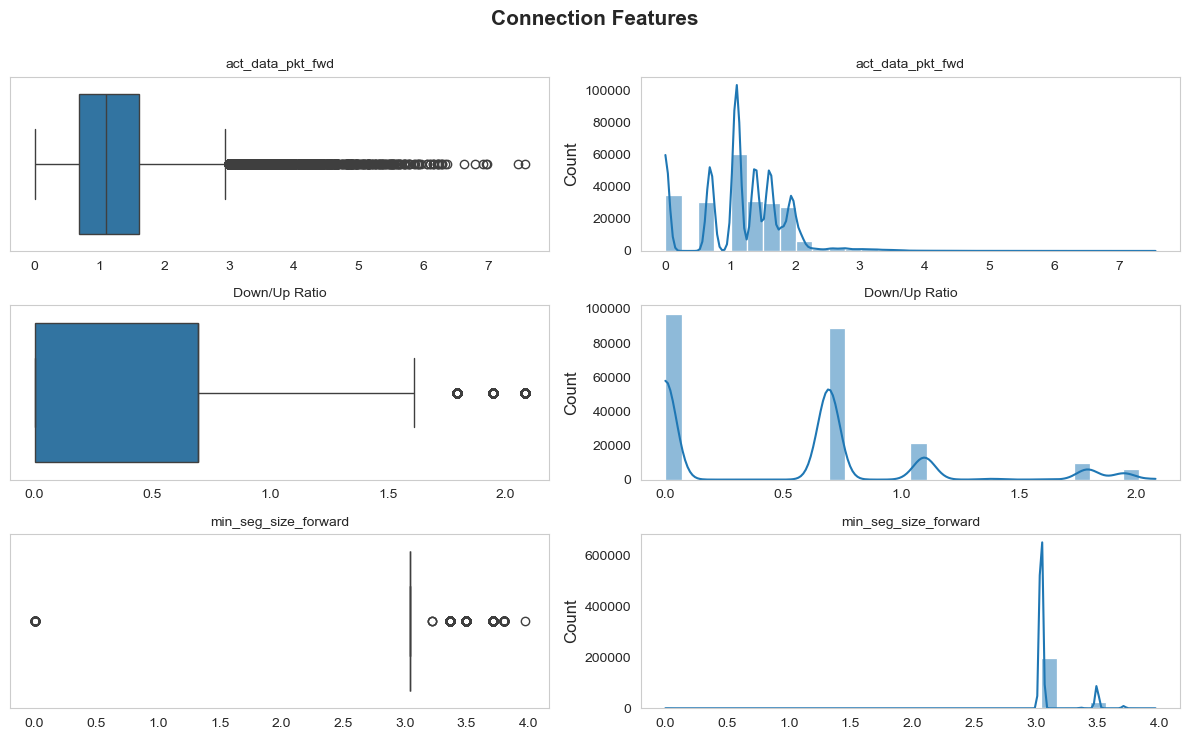

In [8]:
def outlier_analysis(df, features_groups):
    if features_groups is None:
        raise ValueError("features_groups or target is None. Please provide valid values for both parameters.") 
    
    # Avoid modifying original data
    data = df.copy()
    for group_name, features in features_groups.items():

        # Keep only features that exist in the DataFrame
        valid_features = [f for f in features if f in data.columns]

        # Skip empty groups
        if len(valid_features) == 0:
            continue

        rows = len(valid_features)

        fig, axs = plt.subplots(
            rows,
            2,
            figsize=(12, rows * 2.5),
            squeeze=False
        )

        for i, feature in enumerate(valid_features):

            values = data[feature]

            # Boxplot
            sns.boxplot(
                x=values,
                ax=axs[i, 0]
            )
            axs[i, 0].set_title(feature, fontsize=10)
            axs[i, 0].set_xlabel("")

            # Histogram + KDE
            sns.histplot(
                values,
                bins=30,
                kde=True,
                ax=axs[i, 1]
            )
            axs[i, 1].set_title(feature, fontsize=10)
            axs[i, 1].set_xlabel("")

        fig.suptitle(
            group_name,
            fontsize=15,
            fontweight="bold"
        )

        plt.tight_layout(rect=[0, 0, 1, 0.98])
        plt.show()

outlier_analysis(df, log_feature_groups)

## Save Datasets

In [9]:
from src.preprocessing import save
save("stage2/full-225k-log.parquet", df)

Saving dataset as .parquet
Final Dataset Saved: data/processed\stage2/full-225k-log.parquet (23.73 MB) 
